In [2]:
import pandas as pd
import numpy as np

import nltk
import string
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print('done')

done


In [3]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")
df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [5]:
labelValue = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}
df["label"].value_counts()

label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

In [6]:
df.dropna(how='any', inplace=True)
test_df.dropna(how='any', inplace=True)

In [7]:
nlp = spacy.load("en_core_web_sm")
def lemmatize_text(text):    
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

df["lemmatized"] = df["text"].apply(lemmatize_text)


In [8]:
nlp = spacy.load("en_core_web_sm")
def lemmatize_text(text):    
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

test_df["lemmatized"] = test_df["text"].apply(lemmatize_text)


In [9]:
test_df.head()


,text,label,lemmatized
0,im feeling rather rotten so im not very ambiti...,0,I m feel rather rotten so I m not very ambitio...
1,im updating my blog because i feel shitty,0,I m update my blog because I feel shitty
2,i never make her separate from me because i do...,0,I never make she separate from I because I don...
3,i left with my bouquet of red and yellow tulip...,1,I leave with my bouquet of red and yellow tuli...
4,i was feeling a little vain when i did this one,0,I be feel a little vain when I do this one


In [10]:
df["final_text"] = df["lemmatized"].str.lower()
test_df["lemma_text"] = test_df["lemmatized"].str.lower()
df.head()

,text,label,lemmatized,final_text
0,i didnt feel humiliated,0,I do not feel humiliated,i do not feel humiliated
1,i can go from feeling so hopeless to so damned...,0,I can go from feel so hopeless to so damned ho...,i can go from feel so hopeless to so damned ho...
2,im grabbing a minute to post i feel greedy wrong,3,I m grab a minute to post I feel greedy wrong,i m grab a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,2,I be ever feel nostalgic about the fireplace I...,i be ever feel nostalgic about the fireplace i...
4,i am feeling grouchy,3,I be feel grouchy,i be feel grouchy


In [11]:
extra_noise_words = {"im", "ive", "youre", "theyre", "hes", "shes", "weve", 
                      "youve", "id", "ill", "youll"}
stop_words = (set(stopwords.words('english')) - {"not", "no", "nor"}) | extra_noise_words

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stop_words])

df["clean_text"] = df["final_text"].apply(remove_stopwords)
test_df["clean_text"] = test_df["lemma_text"].apply(remove_stopwords)

In [12]:
X_train = df["clean_text"]
y_train = df["label"]
X_test = test_df["clean_text"]
y_test = test_df["label"]

In [13]:
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
nb_bow = MultinomialNB().fit(X_train_bow, y_train)
y_pred = nb_bow.predict(X_test_bow)
print("===== Naive Bayes - BoW =====")
print(classification_report(y_test, y_pred))


nb_tfidf = MultinomialNB().fit(X_train_tfidf, y_train)
y_pred = nb_tfidf.predict(X_test_tfidf)
print("===== Naive Bayes - TF-IDF =====")
print(classification_report(y_test, y_pred))


lr_bow = LogisticRegression(max_iter=1000).fit(X_train_bow, y_train)
y_pred = lr_bow.predict(X_test_bow)
print("===== Logistic Regression - BoW =====")
print(classification_report(y_test, y_pred))


lr_tfidf = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train)
y_pred = lr_tfidf.predict(X_test_tfidf)
print("===== Logistic Regression - TF-IDF =====")
print(classification_report(y_test, y_pred))


svm_bow = LinearSVC().fit(X_train_bow, y_train)
y_pred = svm_bow.predict(X_test_bow)
print("===== SVM - BoW =====")
print(classification_report(y_test, y_pred))


svm_tfidf = LinearSVC().fit(X_train_tfidf, y_train)
y_pred = svm_tfidf.predict(X_test_tfidf)
print("===== SVM - TF-IDF =====")
print(classification_report(y_test, y_pred))

===== Naive Bayes - BoW =====
              precision    recall  f1-score   support

           0       0.75      0.92      0.83       581
           1       0.77      0.96      0.85       695
           2       0.90      0.28      0.43       159
           3       0.90      0.64      0.75       275
           4       0.84      0.63      0.72       224
           5       1.00      0.05      0.09        66

    accuracy                           0.79      2000
   macro avg       0.86      0.58      0.61      2000
weighted avg       0.81      0.79      0.76      2000

===== Naive Bayes - TF-IDF =====
              precision    recall  f1-score   support

           0       0.69      0.91      0.78       581
           1       0.66      0.99      0.79       695
           2       1.00      0.07      0.13       159
           3       0.95      0.33      0.49       275
           4       0.88      0.34      0.49       224
           5       0.00      0.00      0.00        66

    accuracy  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


===== Logistic Regression - BoW =====
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       581
           1       0.88      0.92      0.90       695
           2       0.75      0.67      0.71       159
           3       0.86      0.85      0.86       275
           4       0.87      0.86      0.87       224
           5       0.78      0.59      0.67        66

    accuracy                           0.87      2000
   macro avg       0.84      0.80      0.82      2000
weighted avg       0.87      0.87      0.87      2000

===== Logistic Regression - TF-IDF =====
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       581
           1       0.83      0.95      0.88       695
           2       0.80      0.55      0.65       159
           3       0.89      0.78      0.83       275
           4       0.89      0.81      0.85       224
           5       0.88      0.44      0.59        66

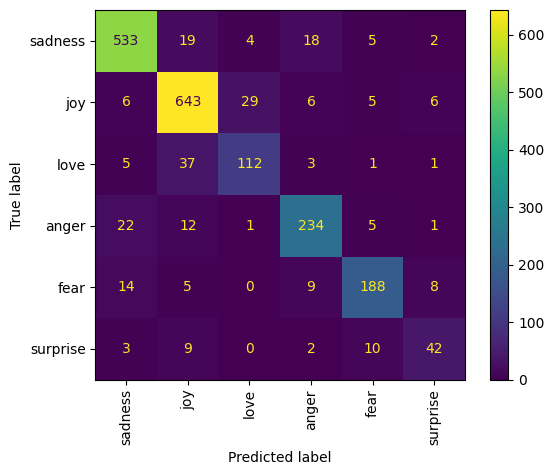

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

emotion_labels = ["sadness", "joy", "love", "anger", "fear", "surprise"]
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=emotion_labels,
    xticks_rotation="vertical"
)